In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plot
from scipy.interpolate import RegularGridInterpolator

from plant.parameters import params
from plant.battery import battery_step, coef_quad, Uoc,thermal_model
from plant.powertrain import powertrain

# Single-lap Dynamic Programming (vectorized)

This notebook reimplements the backward recursion of `01_single_lap_DP.ipynb`
in vectorized form (grid-wide `numpy` operations instead of explicit loops
over states), for the same plant model and cost formulation. See
`01_single_lap_DP.ipynb` for the physical setup, cost function, and results
narrative — this notebook focuses only on the implementation and on
verifying numerical equivalence.

**Inputs**: `data/qualifying_Canada/` velocity profile \
**Outputs**: `u_star`, single-lap SoC/power trajectory plots \
**Depends on**: `plant/battery.py`, `plant/powertrain.py`

In [2]:
#Define the parameters
Delta_t = 0.1

# Fuel consumption in grams per unit energy

Voc = params['V_oc_nom'] 
Q_bat = params['E_pack_capacity'] / Voc

# Limits on Batt Power, Eng Power, SOC
P_MGU_max = params['P_MGU_max']  # 350[kW]
P_MGU_min = params['P_MGU_min']  # -350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]
eta_MGU = params['eta_MGU']

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SOC_min = params['SoC_min']     # 0.2[-]
SOC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']

# Load Data: of t,v,a
data = np.load('/app/data/qualifying_Canada/Canada_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('/app/data/qualifying_Canada/power_domand_quali.npy')
P_gb = data_of_power_gb[1,:]


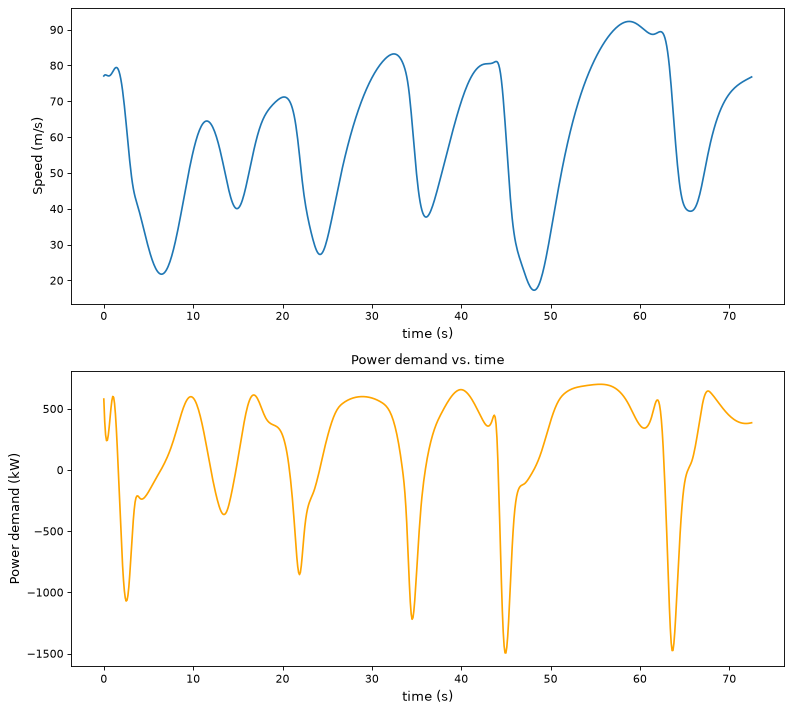

In [3]:

plot.figure(num=1, figsize=(10, 9), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(2,1,1)
plot.plot(t,v)
plot.ylabel('Speed (m/s)', fontsize= 12)
plot.xlabel('time (s)', fontsize= 12)

plot.subplot(2,1,2)
plot.plot(t, P_gb/1e3, 'orange')
plot.xlabel('time (s)', fontsize=12)
plot.ylabel('Power demand (kW)', fontsize=12)
plot.title('Power demand vs. time', fontsize=12)
plot.tight_layout()
plot.show()

In [4]:
SoC_grid = np.linspace(SOC_min,SOC_max, 80)
E_ES2K_grid = np.linspace(0, E_ES2K_max, 150)

#Grid size
ns = len(SoC_grid) # No. of states
ne = len(E_ES2K_grid)

# Planning horizon (time steps)
N = len(t)

# Number of candidate controls per state
nu = 200

In [5]:
SoC_mesh, E_ES2K_mesh = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')

SoC_max_term = (SOC_max - SoC_mesh) * Q_bat * Uoc(SoC_mesh, coef_quad) / -Delta_t
SoC_min_term = (SOC_min - SoC_mesh) * Q_bat * Uoc(SoC_mesh, coef_quad) / -Delta_t
E_deploy_ub = (E_ES2K_max-E_ES2K_mesh)/Delta_t

def backward_iteration(w_shortfall = 0.0):
    """Backward DP recursion.

    w_shortfall: weight [kg/J] on the power shortfall in the stage cost.
        0.0  -> shortfall ignored (ablation run, produces an infeasible policy)
        1e2  -> shortfall penalized, reference run
    """
    # Preallocate Value Function (rows index state, columns index time)
    V = np.inf*np.ones((ns,ne,N+1))

    # Preallocate Control (rows index state, columns index time)
    u_star = np.zeros((ns,ne, N))
    # Boundary Condition of Value Function (Principle of Optimality)
    V[:,:,N] = 0

    for k in range(N-1,-1,-1):
        interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
        if P_gb[k]>=0:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_min, (P_gb[k] - P_eng_max)/eta_MGU))
            ub = np.minimum(SoC_min_term,E_deploy_ub)
            ub = np.minimum(ub, np.minimum(P_MGU_max,P_gb[k]/eta_MGU))
        else:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_min, P_gb[k]* eta_MGU))
            ub = np.minimum(SoC_min_term,0.0)

        infeasible_mask = lb > ub
        lb_safe = np.where(infeasible_mask, 0.0, lb)
        ub_safe = np.where(infeasible_mask, 0.0, ub)
        P_mguk_mesh = np.linspace(lb_safe, ub_safe, nu, axis=-1)


        if P_gb[k]>=0:
            P_eng_req = P_gb[k] - P_mguk_mesh
            P_eng = np.clip(P_eng_req, 0, P_eng_max)
            shortfall = np.maximum(P_gb[k] - (P_eng + P_mguk_mesh), 0)


        else:
            P_eng = np.zeros_like(P_mguk_mesh)
            shortfall = np.zeros_like(P_mguk_mesh)
        

        m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
        m_dot = np.clip(m_dot, 0, params['m_dot_max']/3600)

        # Cost-per-time-step, a.k.a. fuel consumed at each stage (vectorized for all P_batt_grid)
        g_k = m_dot * Delta_t

        # compute next SOC and E_ES2K using dynamics
        SoC_nxt = SoC_mesh[:,:,np.newaxis] - P_mguk_mesh*Delta_t/(Q_bat * Uoc(SoC_mesh[:, :, np.newaxis], coef_quad))
        E_ES2K_next = E_ES2K_mesh[:, :, np.newaxis] + np.maximum(P_mguk_mesh, 0)*Delta_t
        
        # Compute value function at nxt time step (need to interpolate)
        points = np.stack([SoC_nxt.ravel(), E_ES2K_next.ravel()], axis=-1)
        V_nxt = interp_Vnext(points).reshape(ns, ne, nu)

        # Soft contstraint to avoid the penalty in the shortfall
        total_cost = (g_k + V_nxt+ w_shortfall*shortfall*Delta_t).astype(float)

        # Value Function (Principle of Optimality)
        V_k = np.min(total_cost, axis=2)
        idx = np.argmin(total_cost, axis=2, keepdims=True)
        # Save Optimal Control
        u_k = np.take_along_axis(P_mguk_mesh,idx,axis=2).squeeze(axis=-1)


        V[:,:,k] = V_k
        u_star[:,:,k] = u_k
        
    return u_star

## Simulate optimal energy management results

Now that I've solved the DP, I can use the `u_star` \"map\" to optimize battery usage! I do this for five different starting battery charge to understand its impact on fuel consumption and final charge.

In [6]:
def optimize_PHEV(SOC_0,E_ES2K_0, u):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    P_MGUK_sim = np.zeros(N)
    P_eng_sim = np.zeros(N)
    J_sim = np.zeros(N)
    m_dot_sim = np.zeros(N)
    shortfall = np.zeros(N)
    E_recharge_sim = np.zeros(N)
    P_mech_MGU_K_real= np.zeros(N)
    Tbat_sim = np.zeros(N)
    
    # Initialize
    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_recharge_sim[0] = 0
    Tbat_sim[0]=params['T_bat_init']

    # Simulate PHEV Dynamics
    for k in range(0,(N-1)):
        
        interp_u = RegularGridInterpolator((SoC_grid, E_ES2K_grid), u[:,:,k], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[k], E_ES2K_sim[k]]])
        P_MGUK_sim[k] = interp_u(point)[0]
     
        P_eng_sim[k], P_elect_MGU_K, P_mech_MGU_K_real[k], shortfall_L, E_ES2K_sim[k+1], E_recharge_sim[k+1],m_dot_sim[k] = powertrain(P_gb[k], P_MGUK_sim[k], E_ES2K_sim[k], E_recharge_sim[k], params, Delta_t,control_mode='P2')
        SoC_sim[k+1], _, I2_k = battery_step(SoC_sim[k], P_elect_MGU_K, coef_quad, Tbat_sim[k],params,Delta_t)
        
        Tbat_sim[k+1] = thermal_model(I2_k, Tbat_sim[k], params, Delta_t)

        J_sim[k] = m_dot_sim[k]*Delta_t
        shortfall[k] = max(shortfall_L, 0.0) if P_gb[k] > 0 else 0.0
        
    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim, shortfall, P_mech_MGU_K_real



## Simulate optimal energy management results

The `u_star` map from the backward pass is now applied forward through the
full nonlinear plant. Two policies are simulated from the same initial state
(`SoC_0 = 0.90`, `E_ES2K_0 = 0`), differing only in the weight given to the
power shortfall in the stage cost:

- `w_shortfall = 0`: the shortfall is invisible to the optimizer. This run is
  an ablation, not a result — it is kept only to quantify what the penalty buys.
- `w_shortfall = 1e2`: the shortfall is penalized. This is the reference
  single-lap policy consumed by `02_ECMS.ipynb` and `Compare_Controllers.ipynb`.

Comparing the two isolates the effect of the penalty: both runs end at
essentially the same SoC and deploy energy, so any fuel difference between
them corresponds to mechanical work the unpenalized policy simply fails to
deliver.

In [8]:
def report(label, J, SoC, E, sf):
    fuel = np.sum(J) * 1e3
    sf_MJ = np.sum(sf) * Delta_t / 1e6
    print(f"{label:<22} | fuel: {fuel:7.2f} g | SoC: {SoC[-2]:.4f} "
          f"| deploy: {E[-2]/1e6:.3f} MJ | shortfall: {sf_MJ:.3f} MJ")
    return fuel, sf_MJ

# ---shortfall ignored. Diagnostic only, NOT the reference policy ---
u_nopen = backward_iteration(w_shortfall=0.0)

P_MGUK_np, P_eng_np, m_dot_np, J_np, SOC_np, E_ES2K_np, shortfall_np, P_mech_MGU_K_np = optimize_PHEV(0.90, 0.0, u_nopen)
fuel_np, sf_np = report("no penalty (w=0)", J_np, SOC_np, E_ES2K_np, shortfall_np)

np.savez('/app/data/qualifying_Canada/DP_nopenalty_Canada_qualifying.npz', SoC=SOC_np, P_mech_MGUK=P_mech_MGU_K_np, J=J_np,E_ES2K=E_ES2K_np, shortfall=shortfall_np)

# ---Reference run: shortfall penalized. These are the canonical outputs ---
u_optimal = backward_iteration(w_shortfall=1e2)
P_MGUK_sim90, P_eng_sim90, m_dot_sim90, J_sim90, SOC_sim90, E_ES2K_sim90, shortfall90, P_mech_MGU_K_real90 = optimize_PHEV(0.90, 0.0, u_optimal)

fuel_dp, sf_dp = report("penalized (w=1e2)", J_sim90, SOC_sim90, E_ES2K_sim90, shortfall90)

np.save('/app/data/qualifying_Canada/SOC_DP_Canada_qualifying.npy',    SOC_sim90)
np.save('/app/data/qualifying_Canada/shortfall_DP_Canada_qualifying.npy',    shortfall90)
np.save('/app/data/qualifying_Canada/P_MGUK_DP_Canada_qualifying.npy', P_mech_MGU_K_real90)
np.save('/app/data/qualifying_Canada/J_DP_Canada_qualifying.npy',      J_sim90)
np.save('/app/data/qualifying_Canada/E_ES2K_DP_Canada_qualifying.npy', E_ES2K_sim90)

# What the penalty buys, in energy terms
work_missing = (fuel_dp -fuel_np) * 1e-3 * LHV * eta_ICE / 1e6
print(f"\nFuel difference: {fuel_dp - fuel_np:+.2f} g "
      f"({work_missing:.2f} MJ of mechanical work not delivered without the penalty)")
print(f"Shortfall reduced from {sf_np:.3f} MJ to {sf_dp:.3f} MJ")

no penalty (w=0)       | fuel:  628.51 g | SoC: 0.2005 | deploy: 7.962 MJ | shortfall: 3.398 MJ
penalized (w=1e2)      | fuel:  813.03 g | SoC: 0.2000 | deploy: 8.019 MJ | shortfall: 0.032 MJ

Fuel difference: +184.52 g (4.04 MJ of mechanical work not delivered without the penalty)
Shortfall reduced from 3.398 MJ to 0.032 MJ


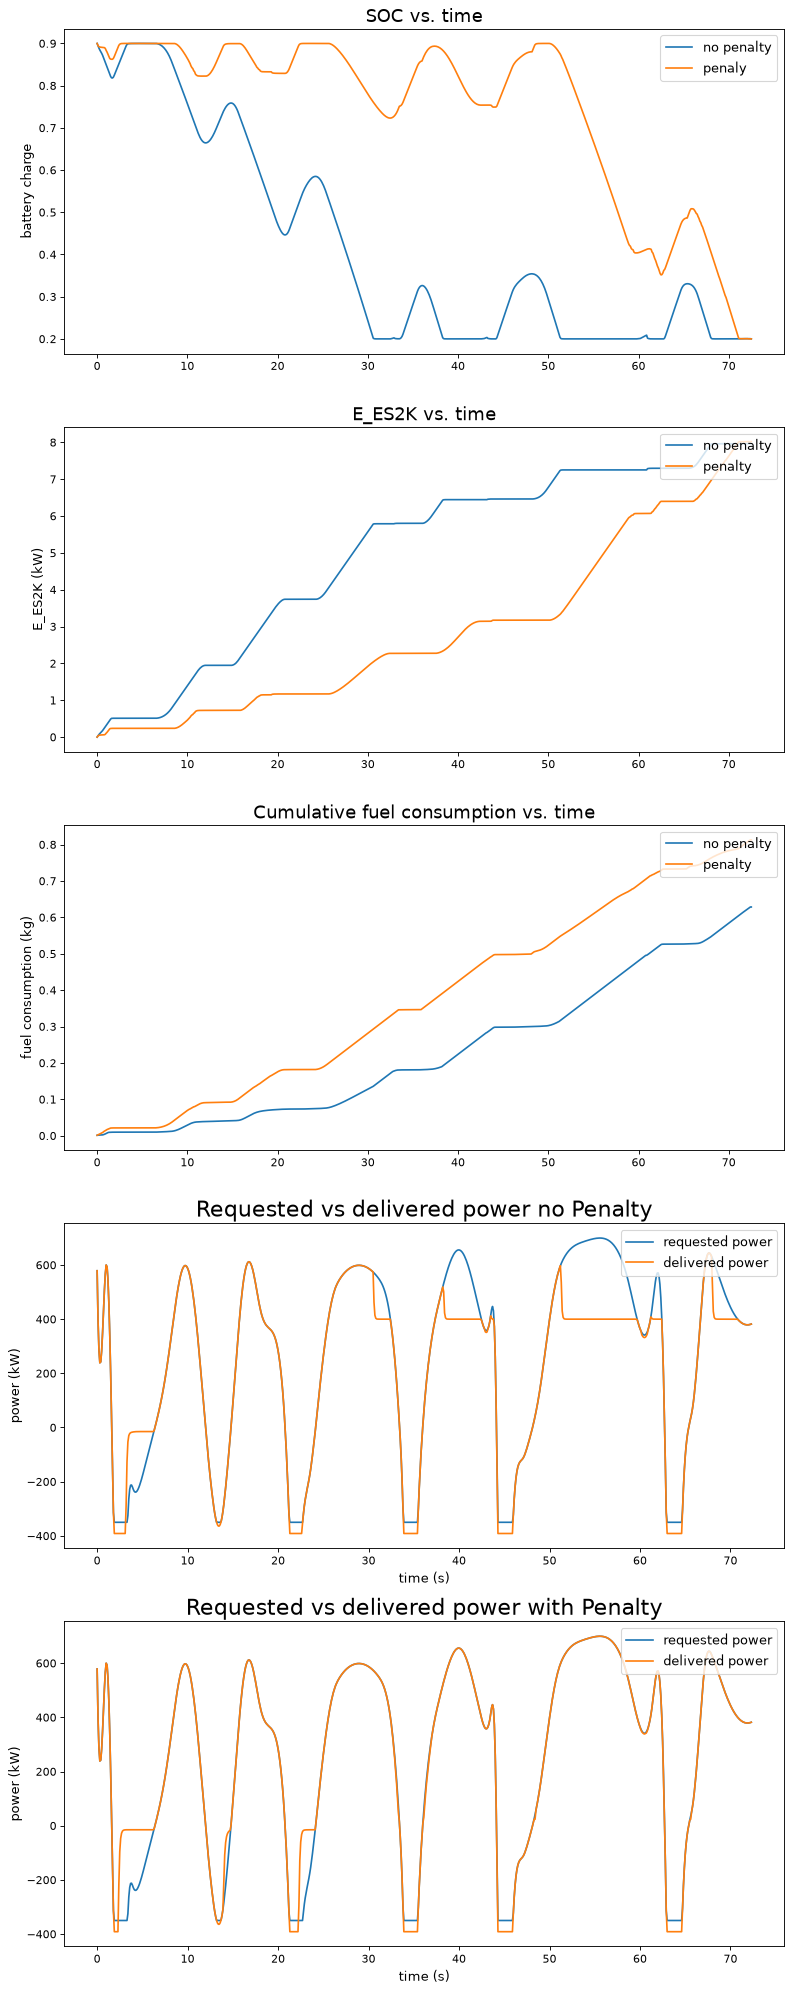

In [9]:
## Plot Simulation Results
plot.figure(num=5, figsize=(10, 25), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(5,1,1)
plot.plot(t, SOC_np,label='no penalty')
plot.plot(t, SOC_sim90,label='penaly')
plot.ylabel('battery charge', fontsize=12)
plot.title('SOC vs. time', fontsize=16)
plot.legend(loc=1, fontsize=12)

plot.subplot(5,1,2)
plot.plot(t, E_ES2K_np/1e6,label='no penalty')
plot.plot(t, E_ES2K_sim90/1e6,label='penalty')
plot.ylabel('E_ES2K (kW)', fontsize=12)
plot.title('E_ES2K vs. time', fontsize=16)
plot.legend(loc=1, fontsize=12)

plot.subplot(5,1,3)
plot.plot(t, np.cumsum(J_np),label='no penalty')
plot.plot(t, np.cumsum(J_sim90),label='penalty')
plot.ylabel('fuel consumption (kg)', fontsize=12)
plot.title('Cumulative fuel consumption vs. time', fontsize=16)
plot.legend(loc=1, fontsize=12)


P_gb2 = np.zeros_like(P_gb)
for k in range(len(P_gb)):
    if P_gb[k]<=P_MGU_min:
        P_gb2[k] = P_MGU_min
    else:
        P_gb2[k]=P_gb[k]

plot.subplot(5,1,4)
plot.plot(t[0:-2], P_gb2[0:-2]/1e3, label='requested power')
plot.plot(t[0:-2], (P_eng_np[0:-2]+P_mech_MGU_K_np[0:-2])/1e3, label='delivered power')
plot.ylabel('power (kW)', fontsize=12)
plot.title('Requested vs delivered power no Penalty', fontsize=20)
plot.xlabel('time (s)', fontsize=12)
plot.legend(loc=1, fontsize=12)


plot.subplot(5,1,5)
plot.plot(t[0:-2], P_gb2[0:-2]/1e3, label='requested power')
plot.plot(t[0:-2], (P_eng_sim90[0:-2]+P_mech_MGU_K_real90[0:-2])/1e3, label='delivered power')
plot.ylabel('power (kW)', fontsize=12)
plot.title('Requested vs delivered power with Penalty', fontsize=20)
plot.xlabel('time (s)', fontsize=12)
plot.legend(loc=1, fontsize=12)



plot.tight_layout()
plot.show()